# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'zahisr2'  # <-- set this
d = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 1.45 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

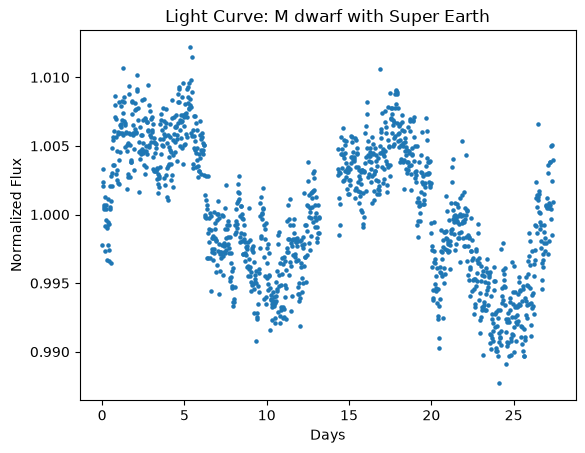

In [3]:
# Part 1: your work here
plt.scatter(t,flux, s = 5) #plotted scatter since the errorbars or line connections were too distracting to see shape
plt.title("Light Curve: M dwarf with Super Earth")
plt.xlabel("Days")
plt.ylabel("Normalized Flux");

In [5]:
import pandas as pd

df = pd.DataFrame({'t': t, 'flux': flux, 'sigma': sigma})
df.index = pd.to_timedelta(df['t'], unit='D') 

WINDOW = '1D'
trend = df['flux'].rolling(WINDOW, center=True, min_periods=10).median()

flux_d  = df['flux'] / trend
sigma_d = df['sigma'] / trend

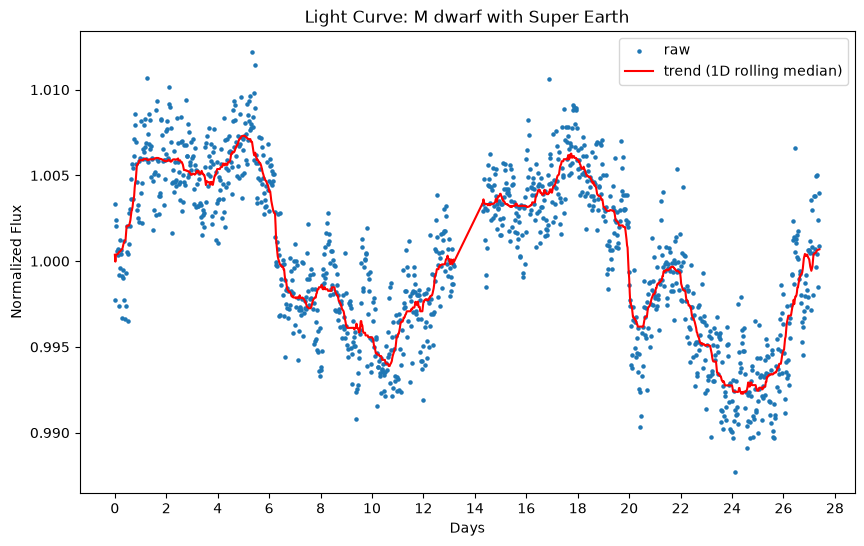

In [7]:
plt.figure(figsize=(10,6))
plt.scatter(t, flux, s=5, label='raw')
plt.plot(df['t'], trend, color='red', lw=1.5, label=f'trend ({WINDOW} rolling median)')
#plt.axvline(1.70, color = 'green', label = 't0 alert = 1.7d')
#plt.axvline(1.70+6.24, color = 'green', label = 'P after t0 = 1.7d + 6.24d')

plt.xticks(np.arange(0, 30, 2))
plt.title("Light Curve: M dwarf with Super Earth")
plt.xlabel("Days")
plt.ylabel("Normalized Flux")
plt.legend();

Duration ~ 6.0
Depth ~ 0.00336


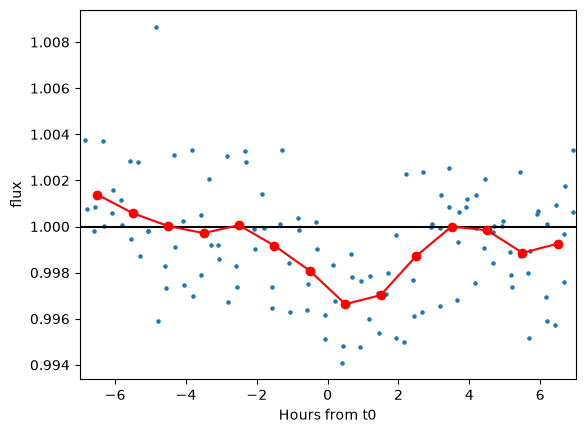

In [9]:
t0_alert, P_alert = 1.70, 6.24 #days
phase = ((t - t0_alert + 0.5*P_alert) % P_alert) - 0.5*P_alert

bins = np.arange(-7, 7.01, 1.0)
idx = np.digitize(phase*24, bins)
centers = 0.5*(bins[1:] + bins[:-1])
binned = [np.mean(flux_d[idx==i+1]) for i in range(len(bins)-1)]

plt.axhline(1,color = 'black')
plt.scatter(phase*24, flux_d, s=5)
plt.plot(centers, binned, 'o-', color='red')
plt.xlim(-7, 7); plt.xlabel('Hours from t0'); plt.ylabel('flux');

print(f'Duration ~ {centers[-4] - centers[4]}')
print(f'Depth ~ {1 - min(binned):.5f}')

In [11]:
oot = np.abs(phase) > 0.15   # outside transit, in days

oot_scatter = np.std(flux_d[oot]) * 1e3   # in ppt
stated = np.median(sigma) * 1e3           # in ppt
print(f"OOT scatter: {oot_scatter:.2f} ppt")
print(f"Stated sigma: {stated:.2f} ppt")
print(f"Ratio: {oot_scatter/stated:.2f}")

OOT scatter: 1.98 ppt
Stated sigma: 1.45 ppt
Ratio: 1.36


**ANSWERS (initial guesses + scatter check):**

Initial guesses:
- t0 = 1.7d
- P = 6.24d
- T = 6 d
- delta = 0.0036

The t0 and P come from the alert written in the header of the data file, while the duration and the depth were estimated from those initial parameters. Out of transit scatter of the detrended flux is much higher than the stated scatter by around 36%, meaning that sigma_flux is underestimating the true noise.

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

In [73]:
# Part 2: your work here
def neg_log_likelihood(theta, t, flux, sigma):
    t0, P, depth, duration, F0 = theta
    model = transit_model(t, t0, P, depth, duration, F0)
    resid = flux - model
    return 0.5 * np.sum(resid**2 / sigma**2 + np.log(2*np.pi*sigma**2))

theta0 = [1.70, 6.24, 0.00336, 6.0/24, 1.0]  # t0, P, depth, duration in d, F0

result = minimize(neg_log_likelihood, theta0, args=(t, flux, sigma),
                  method='Nelder-Mead', options={'maxiter': 50000, 'xatol': 1e-7, 'fatol': 1e-7})

t0_fit, P_fit, depth_fit, dur_fit, F0_fit = result.x
print(f"Converged: {result.success}")
print(f"t0 = {t0_fit:.4f} d")
print(f"P = {P_fit:.4f} d")
print(f"depth = {depth_fit*1e3:.4f} ppt")
print(f"T = {dur_fit*24:.4f} hr")
print(f"F0 = {F0_fit:.6f}")

Converged: True
t0 = 1.6559 d
P = 6.2616 d
depth = 2.8190 ppt
T = 6.5147 hr
F0 = 1.000340


In [74]:
# like hyperparameter tuning
best = None
for T0 in [2/24, 3/24, 4/24, 4.5/24, 5/24, 5.5/24, 6/24, 7/24, 8/24]:
    for d0 in [0.002, 0.0025, 0.003, 0.0035, 0.004, 0.0045, 0.005]:
        start = [1.70, 6.24, d0, T0, 1.0]
        r = minimize(neg_log_likelihood, start, args=(t, flux, sigma), method='Nelder-Mead')
        if best is None or r.fun < best.fun:
            best = r

In [75]:
t0_fit, P_fit, depth_fit, dur_fit, F0_fit = best.x
print(t0_fit, P_fit, depth_fit, dur_fit, F0_fit, best.fun)

1.6145838910375732 6.274730691676185 0.0025149766936216865 0.3541620338814788 1.0003559771752981 -23.078245165943486


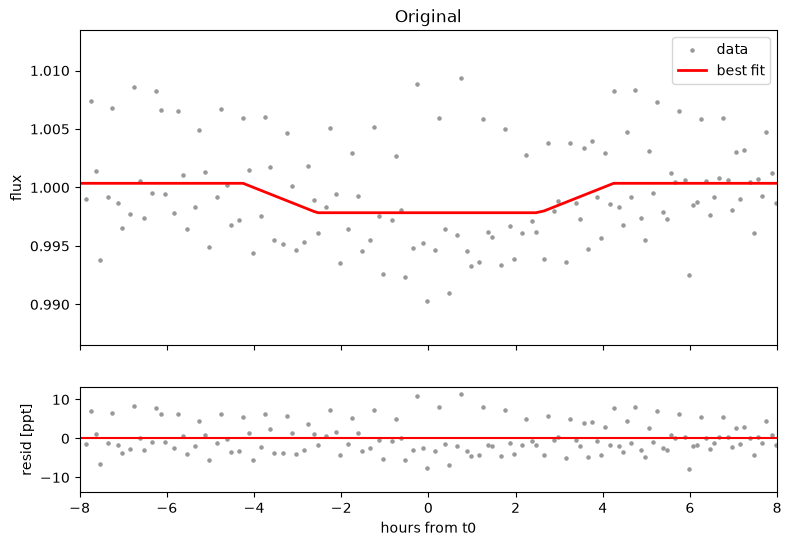

In [77]:
phase = ((t - t0_fit + 0.5*P_fit) % P_fit) - 0.5*P_fit  #mod for folding observaations to make transit more observable
srt = np.argsort(phase)

model_fit = transit_model(t, *best.x)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9,6), sharex=True, gridspec_kw={'height_ratios':[3,1]})
ax1.scatter(phase*24, flux, s=5, color='0.6', label='data')
ax1.plot(phase[srt]*24, model_fit[srt], 'r-', lw=2, label='best fit')
ax1.set_xlim(-8,8)
ax1.legend() 
ax1.set_ylabel('flux')
ax1.set_title("Original")

resid = flux - model_fit
ax2.scatter(phase*24, resid*1e3, s=5, color='0.6')
ax2.axhline(0, color='r')
ax2.set_xlim(-8,8)
ax2.set_xlabel('hours from t0')
ax2.set_ylabel('resid [ppt]');

In [83]:
def numerical_hessian(func, x, eps=1e-5):
    n = len(x)
    H = np.zeros((n, n))
    f0 = func(x)
    for i in range(n):
        for j in range(n):
            xpp = x.copy(); xpp[i]+=eps; xpp[j]+=eps
            xpm = x.copy(); xpm[i]+=eps; xpm[j]-=eps
            xmp = x.copy(); xmp[i]-=eps; xmp[j]+=eps
            xmm = x.copy(); xmm[i]-=eps; xmm[j]-=eps
            H[i,j] = (func(xpp)-func(xpm)-func(xmp)+func(xmm)) / (4*eps**2)
    return H

f = lambda th: neg_log_likelihood(th, t, flux, sigma)
H = numerical_hessian(f, best.x)
cov = np.linalg.inv(H)
sigma_hess = np.sqrt(np.diag(cov))
print("param sigmas (Hessian):", sigma_hess)
print("depth-duration correlation:", cov[2,3]/(sigma_hess[2]*sigma_hess[3]))

param sigmas (Hessian): [3.19314448e-04 3.03816924e-03 2.10152052e-04 4.86273944e-04
 4.18384142e-05]
depth-duration correlation: -0.008471877959154378


In [78]:
n_boot = 500
boot_params = []
for _ in range(n_boot):
    idx = np.random.randint(0, len(t), len(t))
    r = minimize(neg_log_likelihood, best.x, args=(t[idx], flux[idx], sigma[idx]), method='Nelder-Mead')
    if r.success:
        boot_params.append(r.x)
boot_params = np.array(boot_params)
sigma_boot = np.std(boot_params, axis=0)
print("param sigmas (bootstrap):", sigma_boot)
print("parameters:", t0_fit, P_fit, depth_fit, dur_fit)

param sigmas (bootstrap): [0.0750001  0.07058093 0.00076738 0.05624028 0.00013204]
parameters: 1.6145838910375732 6.274730691676185 0.0025149766936216865 0.3541620338814788


In [99]:
#make a table to easily compare
data = {"Params" : ['t0', 'P', 'delta (depth)', 'duration'], 
    "Param Values" : best.x[0:4],
    "sigmas_hess": sigma_hess[0:4],
    "sigmas_boot": sigma_boot[0:4]}

comparison = pd.DataFrame(data)
comparison    

,Params,Param Values,sigmas_hess,sigmas_boot
0,t0,1.614584,0.000319,0.075000
1,P,6.274731,0.003038,0.070581
2,delta (depth),0.002515,0.000210,0.000767
3,duration,0.354162,0.000486,0.056240


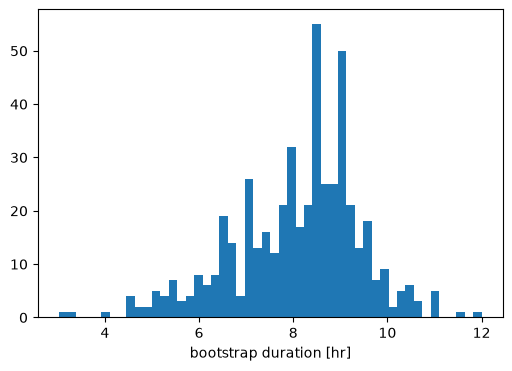

In [111]:
plt.figure(figsize=(6,4))
plt.hist(boot_params[:,3]*24, bins=50)   # duration in hours
plt.xlabel('bootstrap duration [hr]');

**FINAL ANSWER:** $\delta = $ 2.515 $\pm$ 0.000210 ppt, $P = $ 6.275 $\pm$ 0.00304 d, $t_0 = $ 1.615 $\pm$ 0.00319 d

**Which uncertainty and why (a short paragraph):**

The bootstrap is a better method of measuring the uncertainty in each of the parameters over the inverse hessian matrix method; this is because the bootstrap is measuring the variablity in our parameters as the entire dataset itself varies, while the hessian measures more local variability at the best estimate points which assumes that the variability we expect is a symetric peak. When plotting the distribution of the bootstrap parameters, we see bimodal peaks that the Hessian sigma would likely not acccount for as well. As mentioned earlier, the out of transit scatter to stated scatter ratio was high indicating that the stated sigma actually underetimated the true variability. 

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1:* `sigma_emp = np.std(flux_detrended)` -> taking the standard deviation of the entire flux across the out of transit and during the transit causes the entire measurement to be lowered by the dip so that the standard deviation would be much greater.

*Flaw 2:* Chi squared is calculated the same sigma_emp and the verification that its "fully consistent with unity" is not enough to say that it is right its a circular reason. The solution for this would be to fix flaw 1 and consider what variables go into the equation for variables that use past variables.

*Flaw 3:* Ai solution got 6 hours (6/24 days) for the detraining window, and we chose a 1 day window. If the period is around 8 hours, and if the training window is smaller than the actual duration of the transit the estimation must have innacuracy.

In [148]:
# Part 3: demonstrations here

#1
oot = np.abs(phase) > (dur_fit / 2)                        # genuine out-of-transit mask
flux_detrended_ai = flux - trend + 1.0
sigma_emp_all = np.std(flux_detrended_ai)
sigma_emp_oot = np.std(flux_detrended_ai[oot])

print(f"AI sigma_emp (all points, incl. transit): {sigma_emp_all*1e3:.3f} ppt")
print(f"sigma restricted to OOT points only: {sigma_emp_oot*1e3:.3f} ppt")
print(f"stated sigma_flux: {np.median(sigma)*1e3:.3f} ppt")
print("\nAI solution spread much larger than the OOT sigma")
#2
#have to recreate the ai loglikelyhood function
def neg_log_like_ai(theta, tt, ff, sig):
    return 0.5 * np.sum(((ff - transit_model(tt, *theta)) / sig)**2)

theta_ai = [1.70, 6.24, 0.00252, 3.5/24, 1.0]   # AI's fit params, or re-run their minimize() to get exact values

chi2_using_sigma_emp = 2 * neg_log_like_ai(theta_ai, t, flux_detrended_ai, sigma_emp_all) / (len(t) - 5)
chi2_using_stated    = 2 * neg_log_like_ai(theta_ai, t, flux_detrended_ai, sigma) / (len(t) - 5)

print(f"\nchi2_red using their own sigma_emp: {chi2_using_sigma_emp:.3f}")
print(f"chi2_red using stated sigma_flux:   {chi2_using_stated:.3f}")
print("Actual Chi Squared is worse when using a more accurate variability")

#3 #inserting a fake transit from the baseline to see if ai solution can match the depth
from scipy.ndimage import median_filter

np.random.seed(0)
t_test = t.copy()
flux_flat = 1.0 + np.random.normal(0, np.median(sigma), size=len(t_test))

depth_true = 0.0025   # match your own fitted depth
dur_true = dur_fit    # your fitted duration, e.g. ~8.5 hr in days
flux_injected = flux_flat * transit_model(t_test, t0_fit, P_fit, depth_true, dur_true, 1.0)

cadence = np.median(np.diff(t_test))
window = max(3, int(round((6.0 / 24.) / cadence)))
trend_test = median_filter(flux_injected, size=window)
flux_detrended_test = flux_injected - trend_test + 1.0

phase_test = ((t_test - t0_fit + 0.5*P_fit) % P_fit) - 0.5*P_fit
in_tr = np.abs(phase_test) < (dur_true/2 * 0.3)     # innermost, flat-bottom region
recovered_depth = 1.0 - np.median(flux_detrended_test[in_tr])

print(f"\ninjected depth:  {depth_true*1e3:.3f} ppt")
print(f"recovered depth: {recovered_depth*1e3:.3f} ppt")
print(f"fraction lost:   {(depth_true - recovered_depth)/depth_true*100:.1f}%")

AI sigma_emp (all points, incl. transit): 2.022 ppt
sigma restricted to OOT points only: 1.972 ppt
stated sigma_flux: 1.451 ppt

AI solution spread much larger than the OOT sigma

chi2_red using their own sigma_emp: 0.975
chi2_red using stated sigma_flux:   1.892
Actual Chi Squared is worse when using a more accurate variability

injected depth:  2.500 ppt
recovered depth: 0.371 ppt
fraction lost:   85.2%


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**
I used Claude to understand the difference between scipy's detrend function and other library methods vs. using pandas rolling window detrending built in. I also used claude to understand conceptually how it is hard to really see the transit in one observation, but a folded data idea is needed as I have seen in work like pulsar observations. Claude also was used for the code implementation of a few ideas like the histogram diagnostic plot to help me understand the differences in the sigmas, adn the bootstrapping and hessian calculations. I also used Claude to generate the code for the verification implementation after giving it the explanation and plan, and it added the simulated trials.


**VERIFICATION PLAN:**
First we will try and simulate a light curve with chosen parameters to see if the pipeline correctly identifies the transit curve parameters. To evaluate if it was correct, we calculate a pull to see if the answer is within an expected range of the actual result (1 to 2 sigma) which all were as shown below. Failure would look like the parameters above 1-2 sigma which they are not.


In [163]:
t0_true, P_true, depth_true, dur_true, F0_true = best.x  
t_arr   = np.asarray(t)
trend_arr = np.asarray(trend)                             
sigma_arr = np.asarray(sigma)

phase = ((t_arr - t0_true + 0.5*P_true) % P_true) - 0.5*P_true
oot = np.abs(phase) > (dur_true/2)
real_oot_resid = np.asarray((flux - trend)[oot])

def run_one_trial():
    noise_sim = np.random.choice(real_oot_resid, size=len(t_arr), replace=True)
    flux_sim = trend_arr * transit_model(t_arr, t0_true, P_true, depth_true, dur_true, F0_true) + noise_sim

    best_sim = None
    for T0 in [3/24, 6/24, 8/24, 10/24]:
        for d0 in [0.002, 0.0025, 0.003]:
            r = minimize(neg_log_likelihood, [t0_true, P_true, d0, T0, F0_true],
                         args=(t_arr, flux_sim, sigma_arr), method='Nelder-Mead')
            if best_sim is None or r.fun < best_sim.fun:
                best_sim = r
    return best_sim.x

truth = np.array([t0_true, P_true, depth_true, dur_true, F0_true])
names = ['t0', 'P', 'depth', 'duration', 'F0']

pulls = np.array([(run_one_trial() - truth) / sigma_boot for _ in range(30)])

for i, name in enumerate(names):
    print(f"{name}: avg pull={pulls[:,i].mean():.2f}, spread={pulls[:,i].std():.2f}, "
          f"frac within 1sigma={np.mean(np.abs(pulls[:,i])<1):.2f}")

t0: avg pull=-0.10, spread=0.37, frac within 1sigma=1.00
P: avg pull=-0.07, spread=0.18, frac within 1sigma=1.00
depth: avg pull=0.61, spread=0.51, frac within 1sigma=0.73
duration: avg pull=-0.07, spread=1.15, frac within 1sigma=0.77
F0: avg pull=2.74, spread=0.37, frac within 1sigma=0.00
